### Imports and Setup

In [1]:
import os
from scipy.io import wavfile
import numpy as np
import torch
import torch.nn.functional as F
import librosa
import matplotlib.pyplot as plt
import pyproj as proj
import h5py
import itertools
from tqdm.notebook import tqdm

from whale_gunshot_localization import config
from whale_gunshot_localization.utils.experimental import L2Standardize, MultilaterationOpt, WAVReader, ClipAnalyzer, ParLocalizer
from whale_gunshot_localization.models.tcn_archs import TCNRangeAndClassify
from whale_gunshot_localization.utils.transformations import to_spect, get_image_transform_range_classify

Some global setup

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU. Using CPU only.")
    
# derive TOSSIT locations relative to the first from the lat/lons
TOSSIT_latlons = np.asarray([config['TOSSIT']['TOSSIT_lat'], config['TOSSIT']['TOSSIT_lon']]).T
pargs = proj.Proj(proj="aeqd", lat_0=TOSSIT_latlons[0, 0], lon_0=TOSSIT_latlons[0, 1], datum="WGS84", units="m")
xs, ys = pargs(TOSSIT_latlons[:,1], TOSSIT_latlons[:,0]) # np.asarray([config['TOSSIT']['TOSSIT_lat'], config['TOSSIT']['TOSSIT_lon']]).T
TOSSIT_locations = np.asarray([-ys, xs]).T

# get image transforms
preprocessor = L2Standardize(np.load(config['dataset']['data_directory'] + '/mean_range_classification.npy', allow_pickle=True),
                             np.load(config['dataset']['data_directory'] + '/std_range_classification.npy', allow_pickle=True))

# root path to experimental data examples
ccb_data_root = os.path.join(*config['dataset']['ccb_data_directory'].split("/")[:-2],"single_examples")

# load model and weights
model = TCNRangeAndClassify(input_size=232,
                            num_channels=7*[368],
                            kernel_size=6,
                            dropout=0.1).to(device)
state_dict = torch.load(os.path.join(config['models']['checkpoints_directories'], config['models']['model_dir'], 'weights_best.pt'),
                       map_location=device)['model_state_dict']
model.load_state_dict(state_dict)
model.eval();

Using the GPU!


### Helper Functions

In [3]:
def circle(r, a, b):
    """
    Produce points on a circle.
    
    Parameters
    ----------
    r : float
        radius of circle
    a : float
        x coordinate of circle center
    b : float
        y coordinate of circle center
        
    Returns
    -------
    (x, y) : Tuple[array-like, array-like]
        lists of x and y points on the circle perimeter
    """
    
    theta = np.linspace(0, 2*np.pi, 100)
    x = r*np.cos(theta) + a
    y = r*np.sin(theta) + b
    return x, y

def localize(r_p, sensors_idx, TOSSIT_locations):
    """
    Use iterative optimization method to localize a source.
    
    Parameters
    ----------
    r_p : np.ndarray
        predicted ranges
    sensors_idx : np.ndarray
        sensors corresponding to r_p values
    TOSSIT_locations : np.ndarray
        locations of sensors of shape N X 2
        
    Returns
    -------
    loc : np.ndarray
        array of location estimate
    """
    ML = MultilaterationOpt(method_thresh=float('inf'))
    # set geometry
    ML.set_map({
        'TOSSIT_locations' : TOSSIT_locations,
        'min_x' : config['scaling']['min_x'],
        'max_x' : config['scaling']['max_x'],
        'min_y' : config['scaling']['min_y'],
        'max_y' : config['scaling']['max_y'],
    })
        
    _, loc = ML.localize(r_p, sensors_idx)
            
    return loc

def sensor2idx(sensors):
    """
    Convert TOSSIT ID numbers to index in
    the list defined at config['TOSSIT']['ids'].
    
    Parameters
    ----------
    sensors : List[float] or List[int]
        list of sensor IDs
    
    Returns
    -------
    List[Int]
        list of sensor indices
    """
        
    return [config['TOSSIT']['ids'].index(str(int(s))) for s in sensors]

def preprocess_individual_examples(inputs, true_latlon):
    """
    Preprocess individual examples for processing.
    
    Parameters
    ----------
    inputs : np.ndarrray
        input time-domain signals of shape, (N X samples/signal)
    true_latlon : np.ndarray
        true locations associated with the range measurements
    
    Returns
    -------
    inputs : torch.Tensor
        preprocessed spectrograms
    ranges : np.ndarray
        corresponding true ranges
    location_m : np.ndarray
        true source locations
    """

    if len(true_latlon.shape) == 1:
        true_latlon = true_latlon[np.newaxis,:]
    
    # get position and sensor ranges
    location_m = np.zeros(true_latlon.shape)
    ranges = []
    for idx, tll in enumerate(true_latlon):
        xt, yt = pargs(tll[1], tll[0])
        yt = -yt
        location_m[idx,:] = np.asarray([[yt, xt]])
        ranges.extend(np.sqrt(((TOSSIT_locations - location_m[idx,:]) ** 2).sum(axis=1)))
    
    # preprocess
    inputs = preprocessor(inputs)

    return inputs, np.asarray(ranges), location_m

def scan_data(CA, inputs, true_latlon):
    """
    Scans long audio segments from all sensors using model.
    
    Parameters
    ----------
    CA : Clipanalyzer object
        object used to scan audio
    inputs : np.ndarrray
        input time-domain signals of shape, (N X samples/signal)
    true_latlon : np.ndarray
        true locations in lat/lon
        
    Returns
    -------
    rp : List[np.ndarray]
        resulting range predictions on each sensor
    spects : np.ndarray
        preprocessed spectrograms that were detected
    location_m : np.ndarray
        true locations in meters
    """
    
    if len(true_latlon.shape) == 1:
        true_latlon = true_latlon[np.newaxis,:]
    
    # get position and sensor ranges
    location_m = np.zeros(true_latlon.shape)
    for idx, tll in enumerate(true_latlon):
        xt, yt = pargs(tll[1], tll[0])
        yt = -yt
        location_m[idx,:] = np.asarray([[yt, xt]])

    result = CA.process_clips(inputs)

    rp = [x[1] for x in result]
    spects = [x[0] for x in result]
    
    return rp, spects, location_m
    
def plot_range_regression(r_t, r_p):
    """
    Plot true and predicted ranges.
    
    Parameters
    ----------
    r_t : array-like
        true ranges
    r_p : array-like
        predicted ranges
    """
    # get endpoints for identity line
    r_mm = (0, config['scaling']['max_r'] + 5000)
    
    plt.plot(r_t / 1000, r_p / 1000, 'bo', markersize=4)
    plt.plot([r_mm[0] / 1000, r_mm[1] / 1000], [r_mm[0] / 1000, r_mm[1] / 1000], 'r--', label="identity line")
    plt.grid()
    plt.xlabel("True Range [km]")
    plt.ylabel("Predicted Range [km]")
    plt.legend()
    plt.xlim(0, 20)
    plt.ylim(0, 20)
    
def plot_localization(rp, true_loc, sensors, est_loc=None, circles=False):
    """
    Plot true and estimated locations in the context of the TOSSIT sensors.
    
    Parameters
    ----------
    rp : np.ndarray
        ranges
    true_loc :  
    """
    
    if (not isinstance(rp[0], np.ndarray)) and (not isinstance(rp[0], list)):
        rp = [rp]
        
    if (not isinstance(sensors[0], np.ndarray)) and (not isinstance(sensors[0], list)):
        sensors = [sensors]
        
    color_list = ["blue", "red", "green", "purple", "orange", "black"]
    
    # plot TOSSITs
    fliptl = flipy(TOSSIT_locations)
    plt.plot(fliptl[:,1], fliptl[:,0], 'kX', markersize=10, label="TOSSIT", zorder=1)

    # plot predicted location with range circles
    if est_loc is not None:
        if circles:
            for idx_assoc, (assoc_rp, assoc_sensors) in enumerate(zip(rp, sensors)):
                for idx, (r, s) in enumerate(zip(assoc_rp, assoc_sensors)):
                    x, y = circle(r, fliptl[s,1], fliptl[s,0])
                    plt.plot(x, y, '-', linewidth=1, c=color_list[idx_assoc], zorder=0)
        
        if len(est_loc.shape) == 1:
            est_loc = est_loc[np.newaxis, :]
        for idx, el in enumerate(est_loc):
            plt.plot(el[1], el[0], 'ro', markeredgecolor='black', label="Location Estimate" if idx == 0 else None, markersize=10, zorder=2)
    
    # plot true location
    if len(true_loc.shape) == 1:
        true_loc = true_loc[np.newaxis, :]
    for idx, tl in enumerate(true_loc):
        plt.plot(tl[1], tl[0], 'g^', markeredgecolor='black', label="True Location" if idx == 0 else None, markersize=10, zorder=2)
    
def flipy(x):
    xc = x.copy()
    xc[:,0] = -xc[:,0]
    return xc

### Process Data

Grab the acoustic data

In [4]:
idx_list = [[44], [44, 49, 53]]

inputs_short = []
sensors_short = []
true_latlon_short = []
associations_short = []
inputs_long = []
sensors_long = []
true_latlon_long = []
for idx in idx_list:
    # load
    with h5py.File(os.path.join("/",ccb_data_root,"gunshots" + "".join([f"_{i}" for i in idx]) + ".h5"), "r") as f:
        inputs_short.append(f["/data"][:])
        sensors_short.append(f["/sensors"][:].squeeze())
        true_latlon_short.append(f["/location"][:].T)
        associations_short.append(f["/associations"][:].squeeze())

    try:
        with h5py.File(os.path.join("/",ccb_data_root,"gunshots_long" + "".join([f"_{i}" for i in idx]) + ".h5"), "r") as f:
            inputs_long.append(f["/data"][:])
            sensors_long.append(f["/sensors"][:].squeeze())
            true_latlon_long.append(f["/location"][:].T)
        assert (np.array_equal(true_latlon_short[-1], true_latlon_long[-1])), "True locations are different"
    except:
        raise FileNotFoundError("Corresponding long file is not available")

Process the individual examples and manually localize the data

In [5]:
# preprocess the individual examples
inputs_short_pre = []
ranges_short = []
true_location_m_short = []
for i, ll in zip(inputs_short, true_latlon_short):
    isp, rs, tlms = preprocess_individual_examples(i, ll)
    inputs_short_pre.append(isp)
    ranges_short.append(rs)
    true_location_m_short.append(tlms)

# process with model
outputs_short = []
with torch.set_grad_enabled(False):
    for inp in inputs_short_pre:
        inp = inp.to(device)
        out = model(inp).to('cpu')
        outputs_short.append(out)

# extract results
detections_idx = []
rp_short = []
sensors_idx_short = []
associationsp_short = []
for i, out in enumerate(outputs_short):
    detections_idx.append(np.where((F.softmax(out[:,1:], dim=1)[:,1] >= 0.5) & (ranges_short[i] >= config['scaling']['min_r']) & (ranges_short[i] <= config['scaling']['max_r']))[0])
    
    # get predicted ranges and their corresponding sensor indices and source associations
    rp_short.append((out[detections_idx[i],0] * config['scaling']['max_r']).numpy())
    sensors_idx_short.append(np.asarray(sensor2idx(sensors_short[i][detections_idx[i]])))
    associationsp_short.append(associations_short[i][detections_idx[i]])

# manually localize
loc_short = [np.zeros(tlls.shape) for tlls in true_latlon_short]

#
range_assoc_short = []
sensors_assoc_short = []
for sidx, samp in enumerate(associations_short):
    samp_rp = []
    samp_s = []
    for idx, assoc in enumerate(range(len(np.unique(samp)))):
        rp = rp_short[sidx][associationsp_short[sidx] == assoc]
        s = sensors_idx_short[sidx][associationsp_short[sidx] == assoc]
        
        loc_short[sidx][idx,:] = localize(rp, s, TOSSIT_locations)
        
        samp_rp.append(rp)
        samp_s.append(s)
                
    range_assoc_short.append(samp_rp)
    sensors_assoc_short.append(samp_s)

Scan and automatically localize the sources

In [6]:
# get data scanner
data_params = {'fs' : config['signal']['fs'],
               'T' : config['signal']['T'],}
preprocessor = L2Standardize(np.load(config['dataset']['data_directory'] + '/mean_range_classification.npy', allow_pickle=True),
                             np.load(config['dataset']['data_directory'] + '/std_range_classification.npy', allow_pickle=True))
CA = ClipAnalyzer(model, 
                  data_params, 
                  preprocessor,
                  device)

rp_long_list = []
true_location_m_long_list = []
for il, tlll in zip(inputs_long, true_latlon_long):
    rpl, _, tlml = scan_data(CA, il, tlll)
    rp_long_list.append(rpl)
    true_location_m_long_list.append(tlml)

# make linear lists from detections
rp_linear_list = []
sensors_list = []
for rp_long, true_location_m_long in zip(rp_long_list, true_location_m_long_list):
    rp_linear = []
    sensors = []
    for idx, r in enumerate(rp_long):
        for rr in r:
            rp_linear.append(rr)
            sensors.append(idx)
    rp_linear_list.append(rp_linear)
    sensors_list.append(sensors)

assocs_list, loc_list = [], []
for rp_long in tqdm(rp_long_list):
    L = ParLocalizer(k=4, 
                     multilat=MultilaterationOpt(method_thresh=0.95), 
                     consistency_thresh=500, 
                     TOSSIT_locations=TOSSIT_locations, 
                     min_assoc_size=9)

    assocs, loc = L.adaptive_localize(rp_long)
    assocs_list.append(assocs)
    loc_list.append(loc)

sorted_loc_list = []
for locs, true_locs in zip(loc_list, true_location_m_long_list):
    num_ests = loc.shape[0]
    source_loc_combs = np.asarray(list(map(list, itertools.permutations(true_locs))))
    errors_matrix = np.sqrt(((source_loc_combs[:,:num_ests,:] - locs[np.newaxis,:,:]) ** 2).sum(axis=2)).sum(axis=1)
    ordered_source_locs = source_loc_combs[np.argmin(errors_matrix)]
    sorted_loc_list.append(ordered_source_locs)

  0%|          | 0/2 [00:00<?, ?it/s]

In [7]:
range_assoc_long = []
sensors_assoc_long = []
for sidx, assocs in enumerate(assocs_list):
    range_assoc_long.append([])
    sensors_assoc_long.append([])
    for assoc in assocs:
        range_assoc_long[-1].extend([[rp_linear_list[sidx][idx] for idx in assoc]])
        sensors_assoc_long[-1].extend([[sensors_list[sidx][idx] for idx in assoc]])

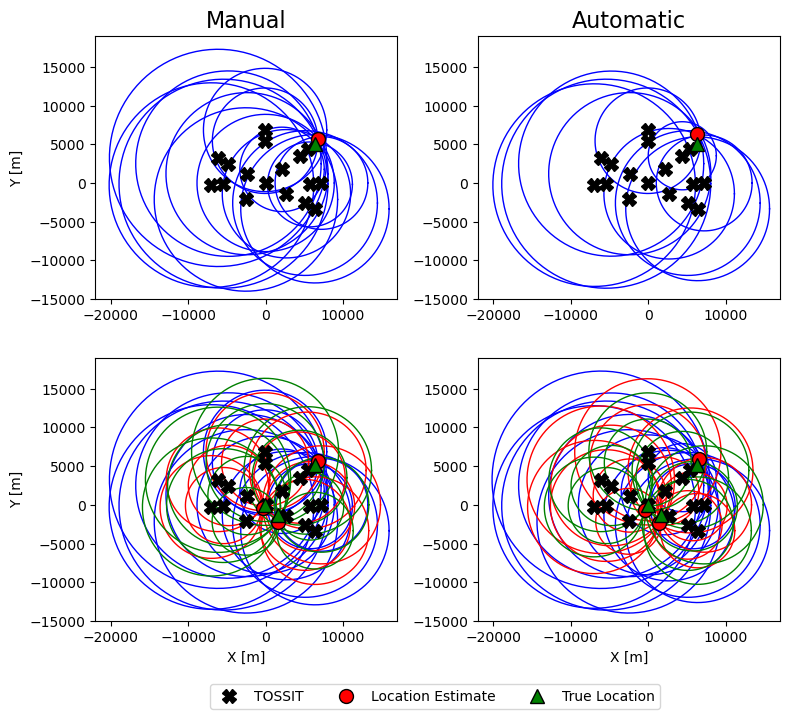

In [11]:
fig, axs = plt.subplots(2, 2)
plt.subplots_adjust(hspace=-0.5)
axs[0,0].set_title("Manual", fontsize=16)
axs[0,1].set_title("Automatic", fontsize=16)

plt.sca(axs[0,0])
plot_localization(range_assoc_short[0], 
                  flipy(true_location_m_short[0]), 
                  sensors_assoc_short[0], 
                  est_loc=flipy(loc_short[0]), 
                  circles=True)
plt.axis('square')
plt.ylim(-15000, 19000)
plt.xlim(-22000, 17000)
plt.ylabel("Y [m]")

plt.sca(axs[1,0])
plot_localization(range_assoc_short[1], flipy(true_location_m_short[1]), sensors_assoc_short[1], est_loc=flipy(loc_short[1]), circles=True)
plt.axis('square')
plt.ylim(-15000, 19000)
plt.xlim(-22000, 17000)
plt.ylabel("Y [m]")
plt.xlabel("X [m]")

plt.sca(axs[0,1])
plot_localization(range_assoc_long[0], flipy(true_location_m_long_list[0]), sensors_assoc_long[0], flipy(loc_list[0]), circles=True)
plt.axis('square')
plt.ylim(-15000, 19000)
plt.xlim(-22000, 17000)
h, l = axs[0,1].get_legend_handles_labels()
fig.legend(h, l, loc='center', bbox_to_anchor=(0.55,0.04), ncol=3)


plt.sca(axs[1,1])
plot_localization(range_assoc_long[1], flipy(true_location_m_long_list[1]), sensors_assoc_long[1], flipy(loc_list[1]), circles=True)
plt.axis('square')
plt.ylim(-15000, 19000)
plt.xlim(-22000, 17000)
plt.xlabel("X [m]")

fig.tight_layout()
fig.show()
plt.savefig("localization_illustrative.png")

In [9]:
print("statistics (automatic)")
print("----------------------")
errors = np.sqrt(((np.concatenate(sorted_loc_list) - np.concatenate(loc_list)) ** 2).sum(axis=1))
print("All Errors: ", errors)
print("RMSE: ", np.around(np.sqrt((errors ** 2).mean()), 2), "m")
print("MAE: ", np.around(errors.mean(), 2), "m\n")

print("statistics (manual)")
print("-------------------")
errors = np.sqrt(((np.concatenate(true_location_m_short) - np.concatenate(loc_short)) ** 2).sum(axis=1))
print("All Errors: ", errors)
print("RMSE: ", np.around(np.sqrt((errors ** 2).mean()), 2), "m")
print("MAE: ", np.around(errors.mean(), 2), "m")

statistics (automatic)
----------------------
All Errors:  [1250.97633001  902.46314322  944.2045221   739.46592294]
RMSE:  976.95 m
MAE:  959.28 m

statistics (manual)
-------------------
All Errors:  [746.09461558 746.09461558 473.54249667 846.28961839]
RMSE:  716.55 m
MAE:  703.01 m
